<a href="https://colab.research.google.com/github/haliaayisha/xai-brain-tumor-segmentation/blob/main/Miniproject_Final_Kaggle_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [ ]:
import os

print(os.listdir("/kaggle/input/datasets"))

['mateuszbuda']


In [ ]:
import os

base_path = "/kaggle/input/datasets/mateuszbuda"
print(os.listdir(base_path))

['lgg-mri-segmentation']


In [ ]:
import os

base_path = "/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation"
print(os.listdir(base_path))

['kaggle_3m', 'lgg-mri-segmentation']


In [ ]:
import os

base_path = "/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m"
print(os.listdir(base_path)[:10])

['TCGA_DU_7010_19860307', 'TCGA_DU_8162_19961029', 'TCGA_FG_A4MT_20020212', 'TCGA_FG_5964_20010511', 'TCGA_DU_A5TS_19970726', 'TCGA_HT_7692_19960724', 'TCGA_DU_5849_19950405', 'TCGA_FG_A60K_20040224', 'TCGA_HT_7475_19970918', 'TCGA_FG_6691_20020405']


In [ ]:
import os
import cv2
import torch
import numpy as np

base_path = "/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m"

image_paths = []
mask_paths = []

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)

    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if "_mask" in file:
                mask_paths.append(os.path.join(folder_path, file))
            elif file.endswith(".tif"):
                image_paths.append(os.path.join(folder_path, file))

In [ ]:
image_paths = sorted(image_paths)
mask_paths = sorted(mask_paths)

In [ ]:
from torch.utils.data import Dataset, DataLoader
import cv2
import torch

class LGGDataset(Dataset):
    def __init__(self, image_paths, mask_paths):
        self.image_paths = image_paths
        self.mask_paths = mask_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = cv2.resize(img, (256,256))
        img = img.transpose(2,0,1)
        img = torch.tensor(img, dtype=torch.float32)

        mask = cv2.imread(self.mask_paths[idx], 0)
        mask = cv2.resize(mask, (256,256))
        mask = torch.tensor(mask/255.0, dtype=torch.float32).unsqueeze(0)

        return img, mask

In [ ]:
dataset = LGGDataset(image_paths, mask_paths)

train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

In [ ]:
imgs, masks = next(iter(train_loader))
print(imgs.shape)
print(masks.shape)

torch.Size([8, 3, 256, 256])
torch.Size([8, 1, 256, 256])


In [ ]:
torch.save(model.state_dict(), "unet_model.pth")
print("Model saved!")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.middle = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))
        d3 = self.down3(self.pool2(d2))

        mid = self.middle(self.pool3(d3))

        u3 = self.up3(mid)
        u3 = torch.cat([u3, d3], dim=1)
        u3 = self.conv3(u3)

        u2 = self.up2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        return self.final(u1)

In [ ]:
import torch.nn as nn

class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        bce = self.bce(pred, target)
        pred = torch.sigmoid(pred)

        intersection = (pred * target).sum()
        dice_loss = 1 - (2 * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)

        return bce + dice_loss

In [ ]:
model = UNet().to(device)

criterion = DiceBCELoss()   # ✅ CHANGE HERE
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(next(model.parameters()).device)

cuda:0


In [ ]:
epochs = 3

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for imgs, masks in train_loader:
        imgs = imgs.to(device)
        masks = masks.to(device).float()

        outputs = model(imgs)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {train_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.8578
Epoch 2, Loss: 0.7393
Epoch 3, Loss: 0.7056


In [ ]:
start_epoch = 4
end_epoch = 10

for epoch in range(start_epoch, end_epoch + 1):
    model.train()
    train_loss = 0

    for imgs, masks in train_loader:
        imgs = imgs.to(device)
        masks = masks.to(device).float()

        outputs = model(imgs)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch {epoch}, Loss: {train_loss/len(train_loader):.4f}")

Epoch 4, Loss: 0.6960
Epoch 5, Loss: 0.6602
Epoch 6, Loss: 0.6719
Epoch 7, Loss: 0.6601
Epoch 8, Loss: 0.6630
Epoch 9, Loss: 0.6367
Epoch 10, Loss: 0.6357


In [ ]:
import torch

def dice_score(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()

    dice = (2. * intersection + smooth) / (union + smooth)
    return dice

In [ ]:
model.eval()

imgs, masks = next(iter(train_loader))
imgs = imgs.to(device)
masks = masks.to(device)

with torch.no_grad():
    preds = model(imgs)

score = dice_score(preds, masks)
print("Dice Score:", score.item())

Dice Score: 0.8045368790626526


In [ ]:
torch.save(model.state_dict(), "unet_lgg_final.pth")

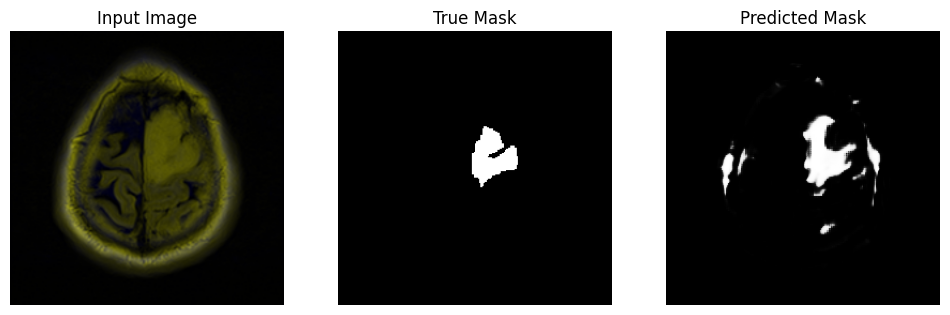

In [ ]:
import matplotlib.pyplot as plt
import torch

model.eval()

imgs, masks = next(iter(train_loader))
imgs = imgs.to(device)
masks = masks.to(device)

with torch.no_grad():
    preds = model(imgs)
    preds = torch.sigmoid(preds)

# move to CPU
imgs = imgs.cpu()
masks = masks.cpu()
preds = preds.cpu()

# visualize first sample
i = 0

plt.figure(figsize=(12,4))

# Input image
plt.subplot(1,3,1)
plt.imshow(imgs[i].permute(1,2,0).numpy().astype("uint8"))
plt.title("Input Image")
plt.axis("off")

# True mask
plt.subplot(1,3,2)
plt.imshow(masks[i][0], cmap="gray")
plt.title("True Mask")
plt.axis("off")

# Predicted mask
plt.subplot(1,3,3)
plt.imshow(preds[i][0], cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

In [ ]:
torch.save(model.state_dict(), "unet_lgg_final.pth")

In [ ]:
model = UNet().to(device)
model.load_state_dict(torch.load("unet_lgg_final.pth", map_location=device))
model.eval()

for module in model.modules():
    if isinstance(module, torch.nn.ReLU):
        module.inplace = False

In [ ]:
activations = None
gradients = None

In [ ]:
def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0]

target_layer = model.down2.conv[3]

h1 = target_layer.register_forward_hook(forward_hook)
h2 = target_layer.register_full_backward_hook(backward_hook)

In [ ]:
img, mask = next(iter(train_loader))

img = img[0:1].to(device)
mask = mask[0:1].to(device)

mask = mask.float()          # ✅ important
img.requires_grad = True

output = model(img)
pred = torch.sigmoid(output)

In [ ]:
model.zero_grad()

# 🔥 choose ONE loss only
loss = torch.sigmoid(output).max()

loss.backward()

In [ ]:
print("grad:", gradients.shape)
print("act:", activations.shape)

grad: torch.Size([1, 128, 128, 128])
act: torch.Size([1, 128, 128, 128])


In [ ]:
weights = gradients.mean(dim=(2,3), keepdim=True)
cam = (weights * activations).sum(dim=1, keepdim=True)

cam = torch.relu(cam)
cam = cam - cam.min()
cam = cam / (cam.max() + 1e-8)

cam = cam.squeeze().detach().cpu().numpy()

In [ ]:
img_np = img.detach().cpu().numpy()[0, 0]

img_np = (img_np - img_np.min()) / (img_np.max() + 1e-8)

In [ ]:
import cv2
cam = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))

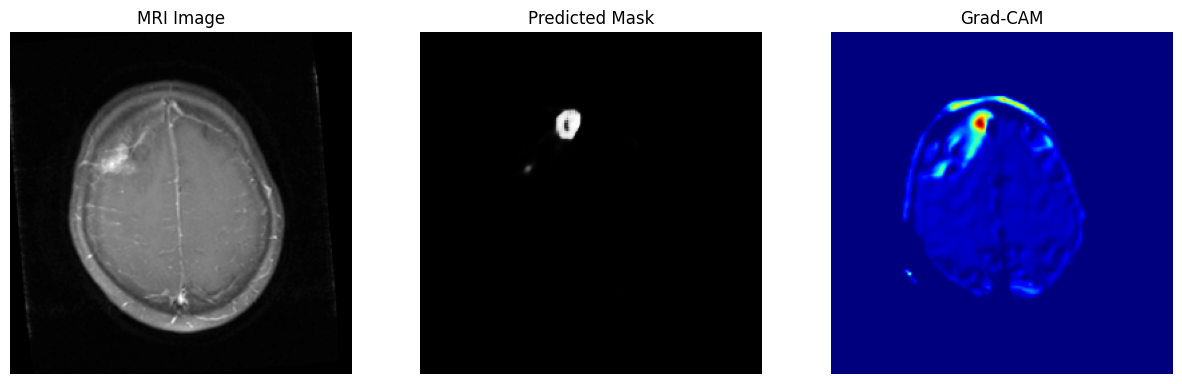

In [ ]:
plt.figure(figsize=(15,5))

# ------------------
# 1. MRI Image
# ------------------
plt.subplot(1,3,1)
plt.imshow(img_np, cmap="gray")
plt.title("MRI Image")
plt.axis("off")

# ------------------
# 2. Prediction Mask
# ------------------
pred_np = pred.detach().cpu().numpy()[0,0]

plt.subplot(1,3,2)
plt.imshow(pred_np, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

# ------------------
# 3. Grad-CAM
# ------------------
plt.subplot(1,3,3)
plt.imshow(cam, cmap="jet")
plt.title("Grad-CAM")
plt.axis("off")

plt.show()